In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

# modelling
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor



In [2]:
df = pd.read_csv('data/studentsperformance.csv')

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
x = df.drop(columns=['math score'],axis=1)
y = df['math score']

In [5]:
print("categories in 'gender' variable: ",end=" ")
print(df['gender'].unique())

print("categories in 'race/ethnicity' variable: ",end=" ")
print(df['race/ethnicity'].unique())

print("categories in 'parental level of education' variable: ",end=" ")
print(df['parental level of education'].unique())

print("categories in 'lunch' variable: ",end=" ")
print(df['lunch'].unique())

print("categories in 'test preparation course' variable: ",end=" ")
print(df['test preparation course'].unique())

categories in 'gender' variable:  ['female' 'male']
categories in 'race/ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
categories in 'parental level of education' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in 'lunch' variable:  ['standard' 'free/reduced']
categories in 'test preparation course' variable:  ['none' 'completed']


In [6]:
## create column transformer with 3 types of transformers
num_features = x.select_dtypes(exclude='object').columns
cat_features = x.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("Onehotencoder",oh_transformer,cat_features),
        ("standardscaler",numeric_transformer,num_features)
    ]
)



In [7]:
x = preprocessor.fit_transform(x)


In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
def evaluate_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r_square = r2_score(true,predicted)
    return rmse,mae,r_square,

In [10]:
models = {
    "linear regression":LinearRegression(),
    'lasso':Lasso(),
    'ridge': Ridge(),
    'k nearest regressor':KNeighborsRegressor(),
    'decision tree':DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'xgboost regressor':XGBRegressor(),
    'catboost regressor':CatBoostRegressor(),
    'adaboost regressor':AdaBoostRegressor()
}

model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train,y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    model_train_rmse,model_train_mae,model_train_r2= evaluate_model(y_train,y_train_pred)
    model_test_rmse,model_test_mae,model_test_r2= evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('model performance for training set')
    print('root mean square error :',model_train_rmse)
    print('mean absolute error',model_train_mae)
    print('r2 score:',model_train_r2)

    print('--------------------------------------')

    print('model performance for testing set')
    print('root mean square error :',model_test_rmse)
    print('mean absolute error',model_test_mae)
    print('r2 score:',model_test_r2)

    r2_list.append(model_test_r2)

    print('====================================================')
    print('\n')


linear regression
model performance for training set
root mean square error : 5.323050852720514
mean absolute error 4.266711846071957
r2 score: 0.8743172040139593
--------------------------------------
model performance for testing set
root mean square error : 5.393993869732843
mean absolute error 4.21476314247485
r2 score: 0.8804332983749565


lasso
model performance for training set
root mean square error : 6.593815587795566
mean absolute error 5.206302661246526
r2 score: 0.8071462015863456
--------------------------------------
model performance for testing set
root mean square error : 6.519694535667419
mean absolute error 5.157881810347763
r2 score: 0.8253197323627853


ridge
model performance for training set
root mean square error : 5.323324922741654
mean absolute error 4.264987823725981
r2 score: 0.8743042615212909
--------------------------------------
model performance for testing set
root mean square error : 5.390387016935642
mean absolute error 4.211100688014261
r2 score: 0.

In [11]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['model_name','r2_score']).sort_values(by=['r2_score'],ascending=False)

,model_name,r2_score
2,ridge,0.880593
0,linear regression,0.880433
8,adaboost regressor,0.853437
7,catboost regressor,0.851632
5,random forest,0.851431
6,xgboost regressor,0.827797
1,lasso,0.825320
3,k nearest regressor,0.783813
4,decision tree,0.751889


## linear regression

In [12]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(x_train,y_train)
y_pred = lin_model.predict(x_test)
score = r2_score(y_test,y_pred)
print("accuracy of the model is %.2f"%score)

accuracy of the model is 0.88


Text(0, 0.5, 'predicted')

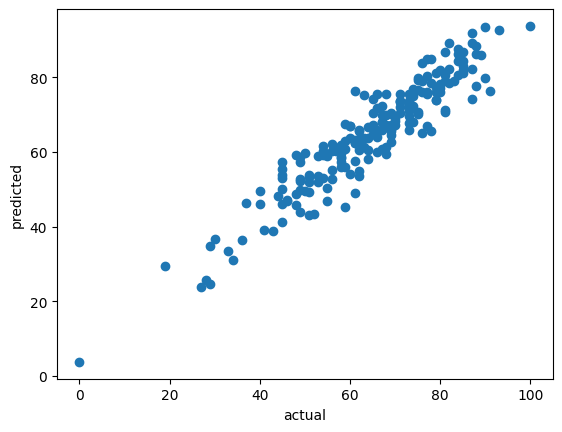

In [13]:
plt.scatter(y_test,y_pred)
plt.xlabel('actual')
plt.ylabel('predicted')

<Axes: xlabel='math score'>

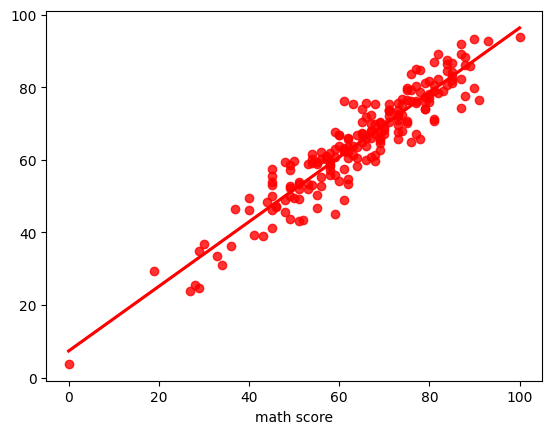

In [14]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')

In [15]:
pred_df = pd.DataFrame({'actual value':y_test,'predicted value':y_pred,'difference':y_test-y_pred})
pred_df

,actual value,predicted value,difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
